# Convolutional Neural Networks (CNNs) – Practical Tutorial on MNIST

**Goal:**  
- Understand the key building blocks of CNNs (convolution, pooling, activation, fully connected layers).  
- Implement and train a CNN on the MNIST handwritten digits dataset using PyTorch.  
- Evaluate performance and visualize some predictions.

**Requirements:**  
- Python 3.x  
- PyTorch, torchvision, matplotlib

In [2]:
# !pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### MNIST Dataset

MNIST consists of 70,000 grayscale images of handwritten digits (0–9), each of size 28×28 pixels.  
We will use 60,000 images for training and 10,000 for testing via `torchvision.datasets.MNIST`.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),                 # Converts H×W×C [0,255] to C×H×W [0,1]
    transforms.Normalize((0.1307,), (0.3081,))  # Standard MNIST normalization[web:3]
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

len(train_dataset), len(test_dataset)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:03<00:00, 2581919.42it/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 94450.79it/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:03<00:00, 538388.66it/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 1514591.25it/s]

Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw



(60000, 10000)

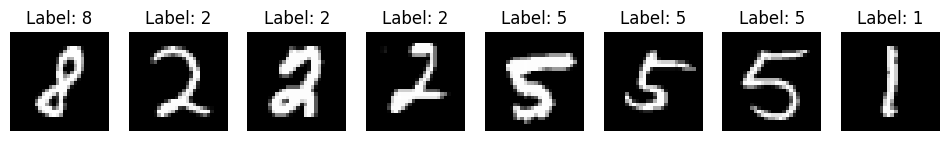

In [4]:
def show_batch(images, labels, n=8):
    images = images[:n]
    labels = labels[:n]
    images = images.squeeze(1).numpy()  # B×28×28

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i], cmap="gray")
        plt.title(f"Label: {labels[i].item()}")
        plt.axis("off")
    plt.show()

images, labels = next(iter(train_loader))
show_batch(images, labels)

### What is a CNN?

A CNN is a neural network specialized for grid-like data (such as images) using three main ideas:
- **Convolution layers:** Learn small filters (kernels) that slide over the image to detect local features (edges, corners, textures).
- **Pooling layers:** Downsample feature maps (e.g., max pooling) to make representations smaller and more robust to small translations.
- **Fully connected layers:** Use the high-level features to perform classification at the end.

### CNN Architecture for MNIST

We will implement a small architecture inspired by common MNIST CNN examples:

- Conv1: 1 input channel → 16 output channels, kernel size 3, padding 1  
- ReLU + MaxPool (2×2)  
- Conv2: 16 → 32 channels, kernel size 3, padding 1  
- ReLU + MaxPool (2×2)  
- Flatten  
- FC1: 32 × 7 × 7 → 128  
- ReLU + Dropout  
- FC2: 128 → 10 (digits 0–9)

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: 1×28×28
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # halves H and W[web:7]
        self.dropout = nn.Dropout(0.25)

        # After two 2×2 pools: 28→14→7, so feature map is 32×7×7
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Block 1: conv → relu → pool
        x = self.pool(F.relu(self.conv1(x)))
        # Block 2: conv → relu → pool
        x = self.pool(F.relu(self.conv2(x)))
        # Flatten
        x = x.view(x.size(0), -1)
        # Fully connected
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # logits
        return x

model = SimpleCNN().to(device)
model


SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

### Loss Function and Optimizer

For multi-class classification, we use **cross-entropy loss** and the **Adam optimizer**.
We will train for a few epochs and track training and test accuracy.

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [8]:
num_epochs = 5

train_losses, train_accs = [], []
test_losses, test_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% "
          f"| Test Loss: {test_loss:.4f} | Test Acc: {test_acc*100:.2f}%")


Epoch [1/5] Train Loss: 0.1774 | Train Acc: 94.64% | Test Loss: 0.0519 | Test Acc: 98.21%
Epoch [2/5] Train Loss: 0.0577 | Train Acc: 98.21% | Test Loss: 0.0346 | Test Acc: 98.80%
Epoch [3/5] Train Loss: 0.0408 | Train Acc: 98.73% | Test Loss: 0.0335 | Test Acc: 98.98%
Epoch [4/5] Train Loss: 0.0342 | Train Acc: 98.89% | Test Loss: 0.0309 | Test Acc: 98.93%
Epoch [5/5] Train Loss: 0.0265 | Train Acc: 99.13% | Test Loss: 0.0316 | Test Acc: 98.96%


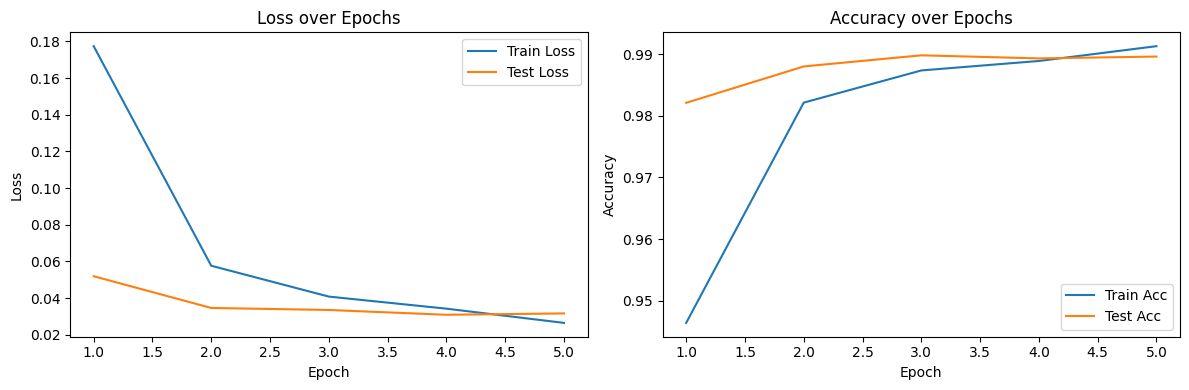

In [9]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label="Train Acc")
plt.plot(epochs, test_accs, label="Test Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

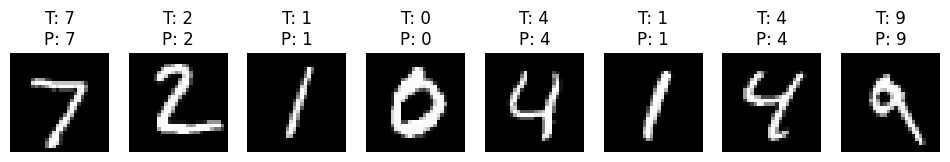

In [10]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images_cpu = images.cpu().squeeze(1).numpy()

n = 8
plt.figure(figsize=(12, 2))
for i in range(n):
    plt.subplot(1, n, i+1)
    plt.imshow(images_cpu[i], cmap="gray")
    plt.title(f"T: {labels[i].item()}\nP: {preds[i].item()}")
    plt.axis("off")
plt.show()

### What You Learned

- How convolutions, pooling, and fully connected layers work together in a CNN.
- How to build, train, and evaluate a simple CNN on MNIST using PyTorch and `torchvision` utilities.

### Possible Extensions

- Add **data augmentation** (random rotations, shifts) to improve generalization.  
- Experiment with different architectures (more conv layers, batch normalization).  
- Try more challenging datasets like CIFAR-10 or Fashion-MNIST with similar code.